In [1]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

!pip install shap xgboost statsmodels --quiet

Mounted at /content/drive


In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import os

print("All imports successful")

All imports successful


In [3]:
#importing data
folder_path = '/content/drive/MyDrive/project/'
output_dir  = '/content/drive/MyDrive/project/results/'
os.makedirs(output_dir, exist_ok=True)

metadata = pd.read_csv(folder_path + 'Source_Data_24Oct2022(subject_metadata).csv',  encoding='latin1')
rel_ab   = pd.read_csv(folder_path + 'Source_Data_24Oct2022(metaphlan_rel_ab).csv',  encoding='latin1')
pathway  = pd.read_csv(folder_path + 'Source_Data_24Oct2022(humann_pathway_counts).csv', encoding='latin1')

print("Metadata:", metadata.shape)
print("Rel abundance:", rel_ab.shape)
print("Pathway counts:", pathway.shape)

Metadata: (724, 57)
Rel abundance: (1107, 725)
Pathway counts: (511, 725)


In [4]:
# PD patient number with target variable
pd_meta = metadata[metadata['Case_status'] == 'PD'].copy()
pd_meta['depression_label'] = (pd_meta['Depression_anxiety_mood_med'] == 'Y').astype(int)

# Healthy controls patient number with target variable
ctrl_meta = metadata[metadata['Case_status'] == 'Control'].copy()
ctrl_meta['depression_label'] = (ctrl_meta['Depression_anxiety_mood_med'] == 'Y').astype(int)

print(f"PD patients:  {len(pd_meta)} | Depressed: {pd_meta['depression_label'].sum()} ({pd_meta['depression_label'].mean():.1%})")
print(f"Controls:     {len(ctrl_meta)} | Depressed: {ctrl_meta['depression_label'].sum()} ({ctrl_meta['depression_label'].mean():.1%})")

PD patients:  490 | Depressed: 180 (36.7%)
Controls:     234 | Depressed: 51 (21.8%)


In [5]:
#cell 5
#preprocessing microbiome data
# Filtering species-level rows and transposing
species_mask = (rel_ab['clade_name'].str.contains('s__') &
                ~rel_ab['clade_name'].str.contains('t__'))
rel_ab_sp = rel_ab[species_mask].copy()
rel_ab_sp['species_short'] = rel_ab_sp['clade_name'].str.split('|').str[-1]
rel_ab_sp = rel_ab_sp.set_index('species_short').drop(columns='clade_name')
rel_ab_T = rel_ab_sp.T
rel_ab_T.index.name = 'sample_name'
print(f"Full species matrix: {rel_ab_T.shape}")

def preprocess_microbiome(df, prevalence=0.10):
    X = df.fillna(0)
    X = X.loc[:, (X > 0).mean(axis=0) >= prevalence]
    X = X.div(X.sum(axis=1), axis=0)
    X_log = np.log(X + 1e-6)
    sel = VarianceThreshold(threshold=0.001)
    arr = sel.fit_transform(X_log)
    return pd.DataFrame(arr, index=X_log.index,
                        columns=X_log.columns[sel.get_support()])

# PD microbiome data
pd_micro_raw = rel_ab_T.loc[rel_ab_T.index.isin(pd_meta['sample_name'])]
X_pd = preprocess_microbiome(pd_micro_raw)
y_pd = pd_meta.set_index('sample_name').loc[X_pd.index, 'depression_label'].values
feature_names = X_pd.columns.tolist()
print(f"PD microbiome:      {X_pd.shape} | Depression rate: {y_pd.mean():.1%}")

# Control microbiome- align to same species as PD
ctrl_micro_raw = rel_ab_T.loc[rel_ab_T.index.isin(ctrl_meta['sample_name'])]
common_sp = [f for f in feature_names if f in ctrl_micro_raw.columns]
X_ctrl_raw = ctrl_micro_raw[common_sp].fillna(0)
X_ctrl_raw = X_ctrl_raw.div(X_ctrl_raw.sum(axis=1), axis=0)
X_ctrl = pd.DataFrame(np.log(X_ctrl_raw + 1e-6),
                      index=X_ctrl_raw.index, columns=common_sp)
y_ctrl = ctrl_meta.set_index('sample_name').loc[X_ctrl.index, 'depression_label'].values
print(f"Control microbiome: {X_ctrl.shape} | Depression rate: {y_ctrl.mean():.1%}")

Full species matrix: (724, 719)
PD microbiome:      (490, 202) | Depression rate: 36.7%
Control microbiome: (234, 202) | Depression rate: 21.8%


In [6]:
#regression analysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests
import numpy as np

p_values = []
odds_ratios = []

for col in X_pd.columns:
    # Reshape single species into column vector
    x = X_pd[col].values.reshape(-1, 1)

    #logistic regression for this species
    lr = LogisticRegression(class_weight='balanced',
                            random_state=42, max_iter=1000)
    lr.fit(x, y_pd)

    # Odds ratio — exponentiated coefficient
    # >1 means species higher in depressed patients
    # <1 means species lower in depressed patients
    odds_ratio = np.exp(lr.coef_[0][0])

    # P-value via likelihood ratio test
    # Compare model with species vs null model (no species)
    null_prob = np.full(len(y_pd), y_pd.mean())
    null_loss = log_loss(y_pd, null_prob)
    model_loss = log_loss(y_pd, lr.predict_proba(x)[:, 1])
    lr_stat = 2 * len(y_pd) * (null_loss - model_loss)
    p = 1 - chi2.cdf(lr_stat, df=1)

    p_values.append(p)
    odds_ratios.append(odds_ratio)

#FDR correction across all species
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

#results table
stats_results = pd.DataFrame({
    'species':     feature_names,
    'odds_ratio':  odds_ratios,
    'p_value':     p_values,
    'p_adjusted':  p_adjusted,
    'significant': reject
}).sort_values('p_adjusted')

print(f"Significant species (FDR < 0.05): {reject.sum()}")
print()
print("Top significant species:")
print(stats_results[stats_results['significant']].head(20).to_string(index=False))

# Save to Drive
stats_results.to_csv(output_dir + 'statistical_analysis.csv', index=False)

Significant species (FDR < 0.05): 0

Top significant species:
Empty DataFrame
Columns: [species, odds_ratio, p_value, p_adjusted, significant]
Index: []


In [7]:
#pathway abundance data cleaning (c)
pathway_T = pathway.set_index(pathway.columns[0]).T
pathway_T.index.name = 'sample_name'

pathway_pd = pathway_T.loc[pathway_T.index.isin(pd_meta['sample_name'])].fillna(0)
pathway_pd = pathway_pd.loc[:, (pathway_pd > 0).mean(axis=0) >= 0.10]
pathway_pd = pathway_pd.div(pathway_pd.sum(axis=1), axis=0)
pathway_log = np.log(pathway_pd + 1e-6)
sel_path = VarianceThreshold(threshold=0.001)
X_path = sel_path.fit_transform(pathway_log)
y_path = pd_meta.set_index('sample_name').loc[pathway_pd.index, 'depression_label'].values

print(f"Pathway feature matrix: {X_path.shape} | Depression rate: {y_path.mean():.1%}")

Pathway feature matrix: (490, 402) | Depression rate: 36.7%


In [8]:
#cleaning metadata
meta_cols = [
    'Age_at_collection', 'Sex', 'BMI', 'Laxatives',
    'Antibiotics_past_3_months', 'Probiotic', 'Pain_med', 'Sleep_aid',
    'Constipation', 'Do_you_smoke', 'Do_you_drink_caffeinated_beverages',
    'Do_you_drink_alcohol', 'Bristol_stool_chart', 'IBS', 'IBD',
    'Diarrhea', 'Blood_pressure_med', 'Cholesterol_med', 'Diabetes_med'
]
meta_cols = [c for c in meta_cols if c in pd_meta.columns]

meta_df = pd_meta[['sample_name', 'depression_label'] + meta_cols].copy()
meta_df = meta_df.set_index('sample_name')
for col in meta_df.columns:
    if meta_df[col].dtype == object:
        le = LabelEncoder()
        meta_df[col] = le.fit_transform(meta_df[col].astype(str))
meta_df = meta_df.fillna(meta_df.median())

X_meta_all = meta_df.drop('depression_label', axis=1).values
y_meta      = meta_df['depression_label'].values

# metadata feature selection
sel_meta = SelectKBest(mutual_info_classif, k='all')
sel_meta.fit(X_meta_all, y_meta)
meta_importance = pd.DataFrame({
    'feature':      meta_cols,
    'mutual_info':  sel_meta.scores_
}).sort_values('mutual_info', ascending=False)

print("Metadata feature importance (mutual information):")
print(meta_importance.to_string(index=False))
meta_importance.to_csv(output_dir + 'metadata_feature_importance.csv', index=False)

# 10 metadata features
top_meta_features = meta_importance.head(10)['feature'].tolist()
X_meta = meta_df[top_meta_features].values
print(f"\nUsing top {len(top_meta_features)} metadata features: {top_meta_features}")

Metadata feature importance (mutual information):
                           feature  mutual_info
                               Sex     0.044021
                         Sleep_aid     0.043924
                          Pain_med     0.013393
                          Diarrhea     0.012370
                               IBS     0.007540
              Do_you_drink_alcohol     0.007376
                               IBD     0.004302
                      Do_you_smoke     0.003964
                      Constipation     0.003154
                               BMI     0.000000
                 Age_at_collection     0.000000
Do_you_drink_caffeinated_beverages     0.000000
                         Laxatives     0.000000
         Antibiotics_past_3_months     0.000000
                         Probiotic     0.000000
               Bristol_stool_chart     0.000000
                Blood_pressure_med     0.000000
                   Cholesterol_med     0.000000
                      Diabetes_med    

In [9]:
#5 main functions
def run_experiment(X_data, y_data, experiment_name):
    print(f"\n{'='*65}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Samples: {len(y_data)} | Depression rate: {y_data.mean():.1%}")
    print(f"{'='*65}")

    if y_data.sum() < 10 or (len(y_data) - y_data.sum()) < 10:
        print("Insufficient class samples — skipping.")
        return None

    X_tv, X_te, y_tv, y_te = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, stratify=y_data)
    X_tr, X_v, y_tr, y_v   = train_test_split(
        X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_te_s  = scaler.transform(X_te)

    models = {
        'Logistic Regression': LogisticRegression(
            penalty='l1', solver='liblinear', C=0.1,
            class_weight='balanced', random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced', random_state=42, n_jobs=-1),
        'SVM': SVC(
            kernel='rbf', C=1.0, probability=True,
            class_weight='balanced', random_state=42),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
            random_state=42, eval_metric='logloss', verbosity=0),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu',
            max_iter=500, random_state=42, early_stopping=True)
    }

    results = {}
    for name, model in models.items():
        model.fit(X_tr_s, y_tr)
        auc = roc_auc_score(y_te, model.predict_proba(X_te_s)[:, 1])
        results[name] = round(auc, 4)
        print(f"  {name}: AUC = {auc:.4f}")

    return results

all_results = {}

In [10]:
#cell 10
# Experiment A, PD- microbiome only
all_results['A: PD Microbiome'] = run_experiment(
    X_pd.values, y_pd, "A — PD Only: Microbiome Relative Abundance")

# Experiment B, Controls- microbiome only
all_results['B: Control Microbiome'] = run_experiment(
    X_ctrl.values, y_ctrl, "B — Controls Only: Microbiome Relative Abundance")

# Experiment C, PD- pathway abundance
all_results['C: PD Pathway'] = run_experiment(
    X_path, y_path, "C — PD Only: Pathway Abundance")

# Experiment D, PD- metadata only
all_results['D: PD Metadata'] = run_experiment(
    X_meta, y_meta, "D — PD Only: Metadata Features Only")

# Experiment E, PD- microbiome + metadata combined
common_idx  = meta_df.index.intersection(X_pd.index)
X_micro_al  = X_pd.loc[common_idx].values
X_meta_al   = meta_df.loc[common_idx, top_meta_features].values
y_combined  = meta_df.loc[common_idx, 'depression_label'].values
X_combined  = np.hstack([X_micro_al, X_meta_al])
print(f"\nCombined matrix shape: {X_combined.shape}")
all_results['E: PD Micro+Meta'] = run_experiment(
    X_combined, y_combined, "E — PD Only: Microbiome + Metadata Combined")

# Experiment F, Train on PD, test on controls
scaler_f   = StandardScaler()
X_pd_s     = scaler_f.fit_transform(X_pd.values)
X_ctrl_s   = scaler_f.transform(X_ctrl.values)
svm_f      = SVC(kernel='rbf', C=1.0, probability=True,
                 class_weight='balanced', random_state=42)
svm_f.fit(X_pd_s, y_pd)
auc_f = roc_auc_score(y_ctrl, svm_f.predict_proba(X_ctrl_s)[:, 1])
print(f"\nExperiment F — Train PD / Test Controls: AUC = {auc_f:.4f}")
all_results['F: PD->Control'] = {
    'Logistic Regression': None, 'Random Forest': None,
    'SVM': round(auc_f, 4), 'XGBoost': None, 'MLP': None
}


EXPERIMENT: A — PD Only: Microbiome Relative Abundance
Samples: 490 | Depression rate: 36.7%
  Logistic Regression: AUC = 0.5582
  Random Forest: AUC = 0.5565
  SVM: AUC = 0.6026
  XGBoost: AUC = 0.5121
  MLP: AUC = 0.5990

EXPERIMENT: B — Controls Only: Microbiome Relative Abundance
Samples: 234 | Depression rate: 21.8%
  Logistic Regression: AUC = 0.6595
  Random Forest: AUC = 0.5838
  SVM: AUC = 0.5595
  XGBoost: AUC = 0.6405
  MLP: AUC = 0.5892

EXPERIMENT: C — PD Only: Pathway Abundance
Samples: 490 | Depression rate: 36.7%
  Logistic Regression: AUC = 0.5573
  Random Forest: AUC = 0.5627
  SVM: AUC = 0.5190
  XGBoost: AUC = 0.5636
  MLP: AUC = 0.4884

EXPERIMENT: D — PD Only: Metadata Features Only
Samples: 490 | Depression rate: 36.7%
  Logistic Regression: AUC = 0.6340
  Random Forest: AUC = 0.6711
  SVM: AUC = 0.6606
  XGBoost: AUC = 0.6277
  MLP: AUC = 0.4624

Combined matrix shape: (490, 212)

EXPERIMENT: E — PD Only: Microbiome + Metadata Combined
Samples: 490 | Depression

In [11]:
#AUC table
summary_table = pd.DataFrame(all_results).T
print("\n" + "="*75)
print("MASTER AUC COMPARISON TABLE")
print("="*75)
print(summary_table.to_string())
summary_table.to_csv(output_dir + 'master_auc_table.csv')


MASTER AUC COMPARISON TABLE
                       Logistic Regression  Random Forest     SVM  XGBoost     MLP
A: PD Microbiome                    0.5582         0.5565  0.6026   0.5121  0.5990
B: Control Microbiome               0.6595         0.5838  0.5595   0.6405  0.5892
C: PD Pathway                       0.5573         0.5627  0.5190   0.5636  0.4884
D: PD Metadata                      0.6340         0.6711  0.6606   0.6277  0.4624
E: PD Micro+Meta                    0.6138         0.6573  0.6178   0.6223  0.5914
F: PD->Control                         NaN            NaN  0.5439      NaN     NaN


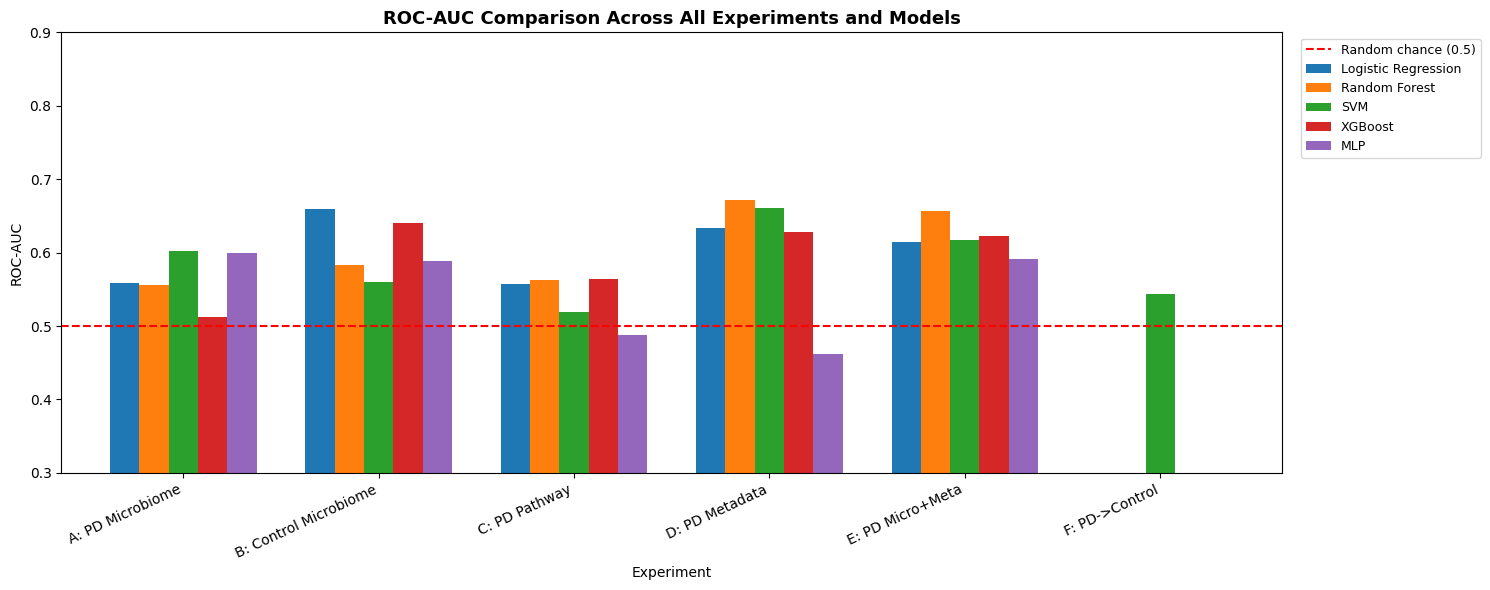

In [12]:
#model comparison graph
fig, ax = plt.subplots(figsize=(15, 6))
plot_df = summary_table.copy().astype(float)
plot_df.plot(kind='bar', ax=ax, width=0.75)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random chance (0.5)')
ax.set_title('ROC-AUC Comparison Across All Experiments and Models', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_xlabel('Experiment')
ax.set_ylim(0.3, 0.9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(output_dir + 'master_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

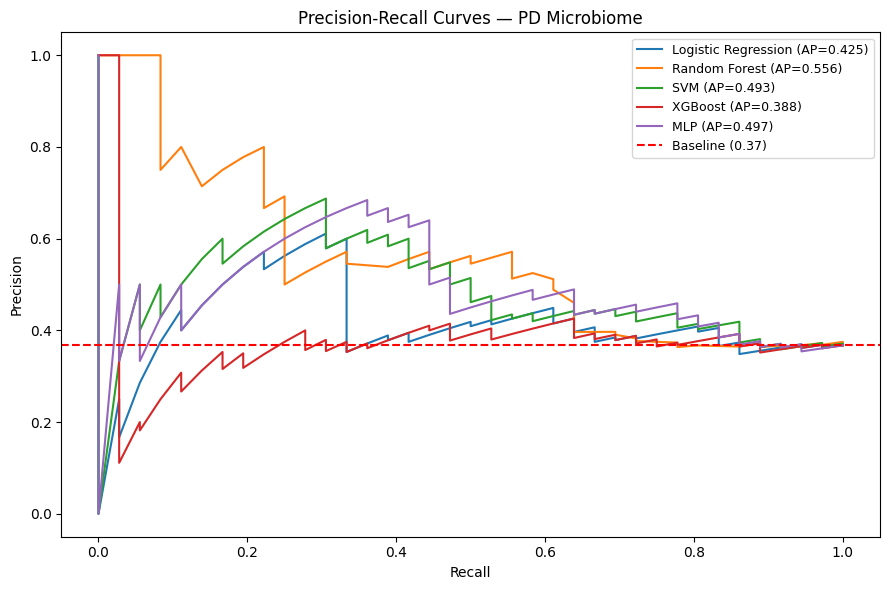

In [13]:
#precision recall curve
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_pd.values, y_pd, test_size=0.2, random_state=42, stratify=y_pd)
sc2    = StandardScaler()
X_tr2s = sc2.fit_transform(X_tr2)
X_te2s = sc2.transform(X_te2)

fig, ax = plt.subplots(figsize=(9, 6))
pr_models = {
    'Logistic Regression': LogisticRegression(penalty='l1', solver='liblinear',
        C=0.1, class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200,
        class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', probability=True,
        class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(verbosity=0, random_state=42, eval_metric='logloss'),
    'MLP': MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500,
        random_state=42, early_stopping=True)
}
for name, m in pr_models.items():
    m.fit(X_tr2s, y_tr2)
    probs = m.predict_proba(X_te2s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_te2, probs)
    ap = average_precision_score(y_te2, probs)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

ax.axhline(y_pd.mean(), color='red', linestyle='--', label=f'Baseline ({y_pd.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — PD Microbiome')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output_dir + 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#bootstrap comparison
def bootstrap_compare(y_true, probs1, probs2, name1, name2, n=1000):
    diffs = []
    rng = np.random.default_rng(42)
    for _ in range(n):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        try:
            d = roc_auc_score(y_true[idx], probs1[idx]) - \
                roc_auc_score(y_true[idx], probs2[idx])
            diffs.append(d)
        except: pass
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    sig = 'YES' if lo > 0 else 'NO'
    print(f"{name1} vs {name2}: diff={np.mean(diffs):.4f}, 95%CI=[{lo:.4f},{hi:.4f}], Significant={sig}")

# Re-train top models on PD test set for comparison
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_pd.values, y_pd, test_size=0.2, random_state=42, stratify=y_pd)
sc3    = StandardScaler()
X_tr3s = sc3.fit_transform(X_tr3)
X_te3s = sc3.transform(X_te3)

svm3 = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
rf3  = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
lr3  = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                           class_weight='balanced', random_state=42, max_iter=1000)
xgb3 = XGBClassifier(verbosity=0, random_state=42, eval_metric='logloss')
mlp3 = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42, early_stopping=True)

probs = {}
for name, m in [('SVM',svm3),('Random Forest',rf3),
                ('Logistic Regression',lr3),('XGBoost',xgb3),('MLP',mlp3)]:
    m.fit(X_tr3s, y_tr3)
    probs[name] = m.predict_proba(X_te3s)[:,1]
    print(f"{name}: AUC = {roc_auc_score(y_te3, probs[name]):.4f}")

print("\nPairwise bootstrap comparisons:")
model_names = list(probs.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        n1, n2 = model_names[i], model_names[j]
        bootstrap_compare(y_te3, probs[n1], probs[n2], n1, n2)

SVM: AUC = 0.6259
Random Forest: AUC = 0.6183
Logistic Regression: AUC = 0.5591
XGBoost: AUC = 0.5139
MLP: AUC = 0.6335

Pairwise bootstrap comparisons:
SVM vs Random Forest: diff=0.0080, 95%CI=[-0.0644,0.0789], Significant=NO
SVM vs Logistic Regression: diff=0.0664, 95%CI=[-0.0091,0.1436], Significant=NO
SVM vs XGBoost: diff=0.1111, 95%CI=[0.0107,0.2106], Significant=YES
SVM vs MLP: diff=-0.0060, 95%CI=[-0.1068,0.0966], Significant=NO
Random Forest vs Logistic Regression: diff=0.0584, 95%CI=[-0.0666,0.1739], Significant=NO
Random Forest vs XGBoost: diff=0.1031, 95%CI=[-0.0024,0.2135], Significant=NO
Random Forest vs MLP: diff=-0.0140, 95%CI=[-0.1090,0.0821], Significant=NO
Logistic Regression vs XGBoost: diff=0.0446, 95%CI=[-0.0720,0.1541], Significant=NO
Logistic Regression vs MLP: diff=-0.0724, 95%CI=[-0.2015,0.0558], Significant=NO
XGBoost vs MLP: diff=-0.1171, 95%CI=[-0.2505,0.0202], Significant=NO


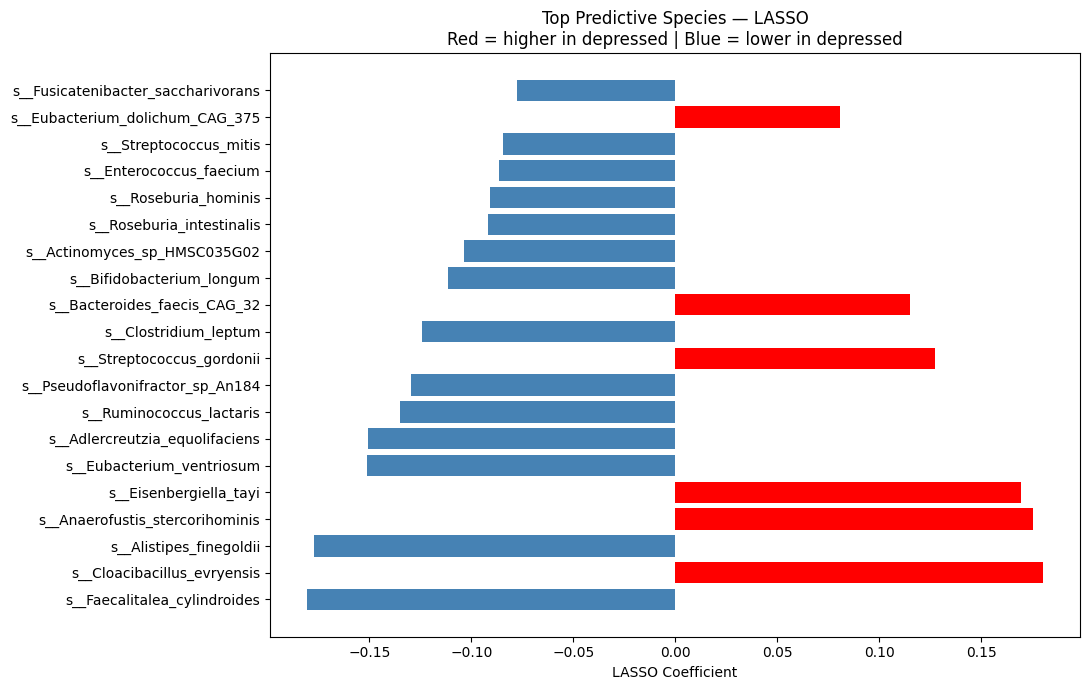

Non-zero species selected by LASSO: 49


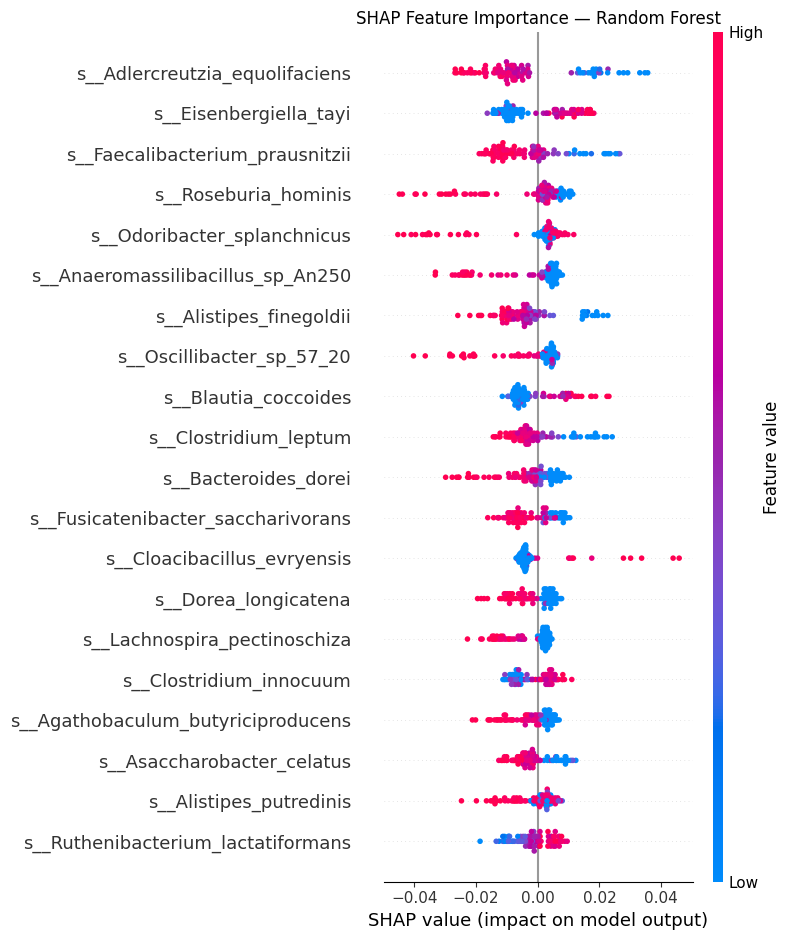

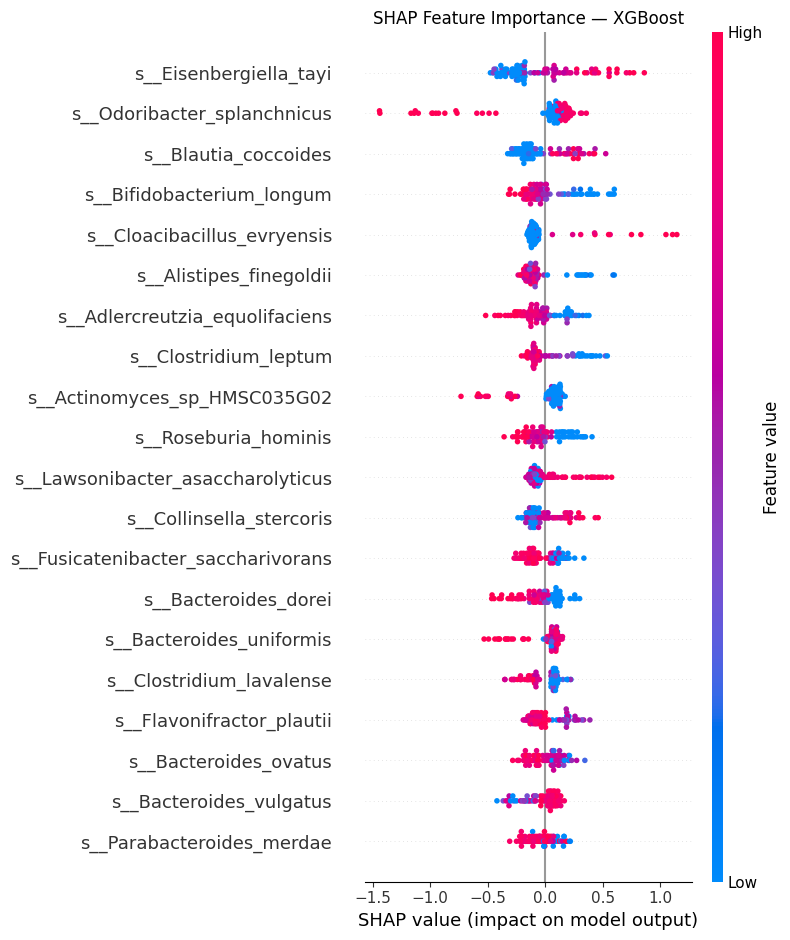

In [15]:
#SHAP analysis
X_tr4, X_te4, y_tr4, y_te4 = train_test_split(
    X_pd.values, y_pd, test_size=0.2, random_state=42, stratify=y_pd)
sc4    = StandardScaler()
X_tr4s = sc4.fit_transform(X_tr4)
X_te4s = sc4.transform(X_te4)

# LASSO coefficients
lr4 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                          class_weight='balanced', random_state=42, max_iter=1000)
lr4.fit(X_tr4s, y_tr4)
coef_df = pd.DataFrame({'species': feature_names, 'coefficient': lr4.coef_[0]})
coef_df = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)
top20   = coef_df.head(20)

plt.figure(figsize=(11, 7))
colors = ['red' if c > 0 else 'steelblue' for c in top20['coefficient']]
plt.barh(top20['species'], top20['coefficient'], color=colors)
plt.xlabel('LASSO Coefficient')
plt.title('Top Predictive Species — LASSO\nRed = higher in depressed | Blue = lower in depressed')
plt.tight_layout()
plt.savefig(output_dir + 'lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Non-zero species selected by LASSO: {len(coef_df)}")
coef_df.to_csv(output_dir + 'lasso_coefficients.csv', index=False)

# SHAP for Random Forest
rf4 = RandomForestClassifier(n_estimators=200, max_depth=10,
                              class_weight='balanced', random_state=42, n_jobs=-1)
rf4.fit(X_tr4s, y_tr4)
explainer  = shap.TreeExplainer(rf4)
shap_vals  = explainer.shap_values(X_te4s)
sv         = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
sv_flat    = sv if sv.ndim == 2 else sv[:, :, 1]

plt.figure(figsize=(11, 8))
shap.summary_plot(sv_flat, X_te4s, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig(output_dir + 'shap_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP for XGBoost
xgb4 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                      random_state=42, eval_metric='logloss', verbosity=0)
xgb4.fit(X_tr4s, y_tr4)
explainer_xgb = shap.TreeExplainer(xgb4)
shap_xgb      = explainer_xgb.shap_values(X_te4s)

plt.figure(figsize=(11, 8))
shap.summary_plot(shap_xgb, X_te4s, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig(output_dir + 'shap_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# Save SHAP importance
shap_imp = pd.DataFrame({
    'species': feature_names,
    'mean_abs_shap_rf': np.abs(sv_flat).mean(axis=0)
}).sort_values('mean_abs_shap_rf', ascending=False)
shap_imp.to_csv(output_dir + 'shap_importance_rf.csv', index=False)

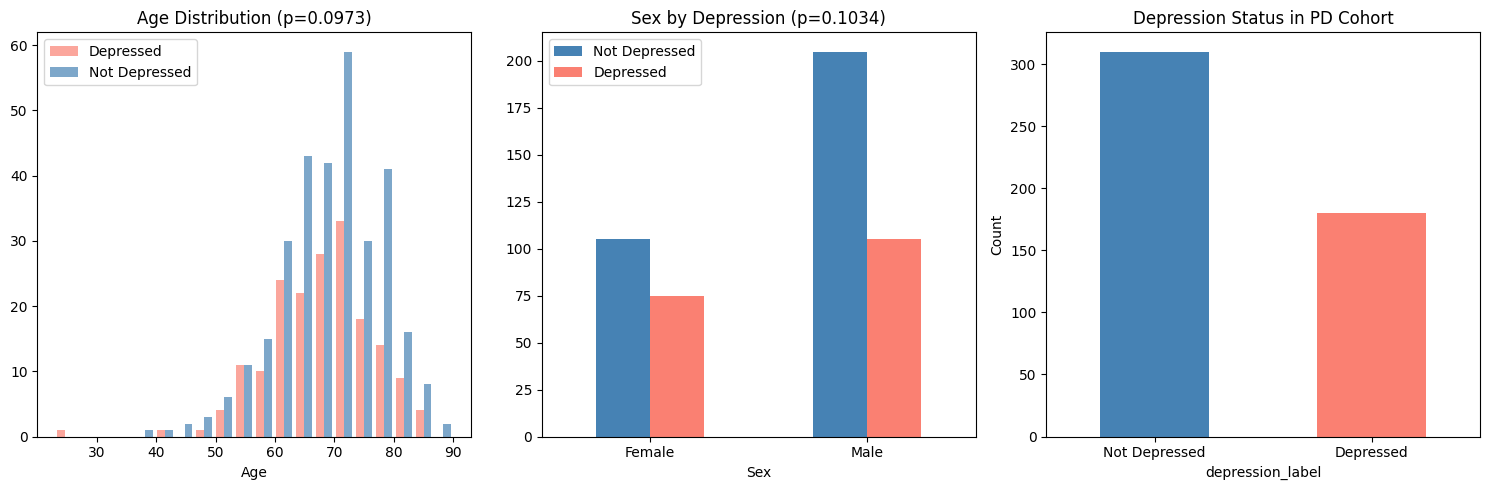

In [16]:
#metadata analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dep_g     = pd_meta[pd_meta['depression_label'] == 1]
not_dep_g = pd_meta[pd_meta['depression_label'] == 0]

# Age
axes[0].hist([dep_g['Age_at_collection'], not_dep_g['Age_at_collection']],
             bins=20, label=['Depressed','Not Depressed'],
             alpha=0.7, color=['salmon','steelblue'])
_, p_age = stats.mannwhitneyu(dep_g['Age_at_collection'],
                               not_dep_g['Age_at_collection'])
axes[0].set_title(f'Age Distribution (p={p_age:.4f})')
axes[0].set_xlabel('Age')
axes[0].legend()

# Sex
sex_tab = pd.crosstab(pd_meta['Sex'], pd_meta['depression_label'])
sex_tab.plot(kind='bar', ax=axes[1], color=['steelblue','salmon'])
_, p_sex, _, _ = stats.chi2_contingency(sex_tab)
axes[1].set_title(f'Sex by Depression (p={p_sex:.4f})')
axes[1].set_xticklabels(['Female','Male'], rotation=0)
axes[1].legend(['Not Depressed','Depressed'])

# Depression counts
pd_meta['depression_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=['steelblue','salmon'])
axes[2].set_title('Depression Status in PD Cohort')
axes[2].set_xticklabels(['Not Depressed','Depressed'], rotation=0)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(output_dir + 'metadata_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

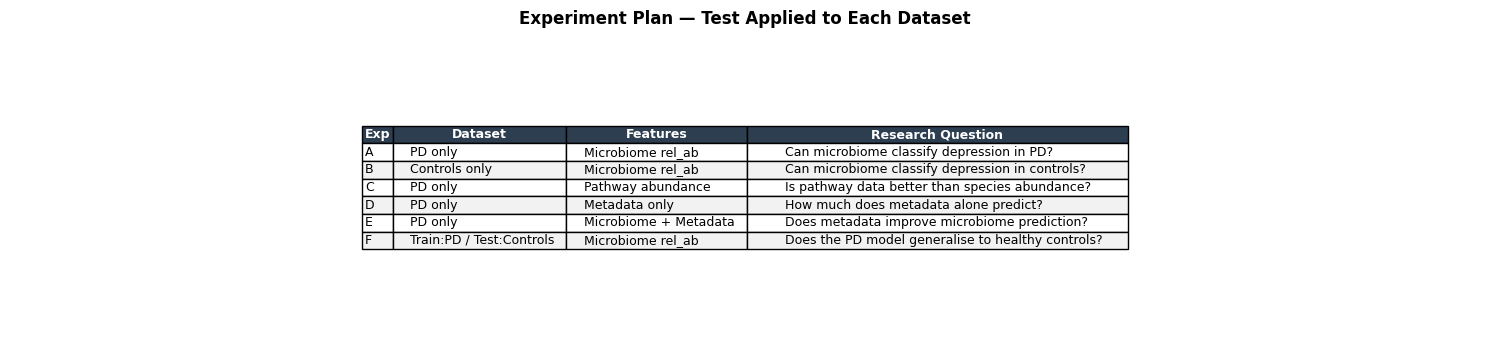

In [17]:
#experiment plan diagram
plan = pd.DataFrame({
    'Exp': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Dataset': ['PD only', 'Controls only', 'PD only',
                'PD only', 'PD only', 'Train:PD / Test:Controls'],
    'Features': ['Microbiome rel_ab', 'Microbiome rel_ab', 'Pathway abundance',
                 'Metadata only', 'Microbiome + Metadata', 'Microbiome rel_ab'],
    'Research Question': [
        'Can microbiome classify depression in PD?',
        'Can microbiome classify depression in controls?',
        'Is pathway data better than species abundance?',
        'How much does metadata alone predict?',
        'Does metadata improve microbiome prediction?',
        'Does the PD model generalise to healthy controls?'
    ]
})

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.axis('off')
tbl = ax.table(cellText=plan.values, colLabels=plan.columns,
               cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(plan.columns))))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f2f2f2')
plt.title('Experiment Plan — Test Applied to Each Dataset',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(output_dir + 'experiment_plan.png', dpi=150, bbox_inches='tight')
plt.show()

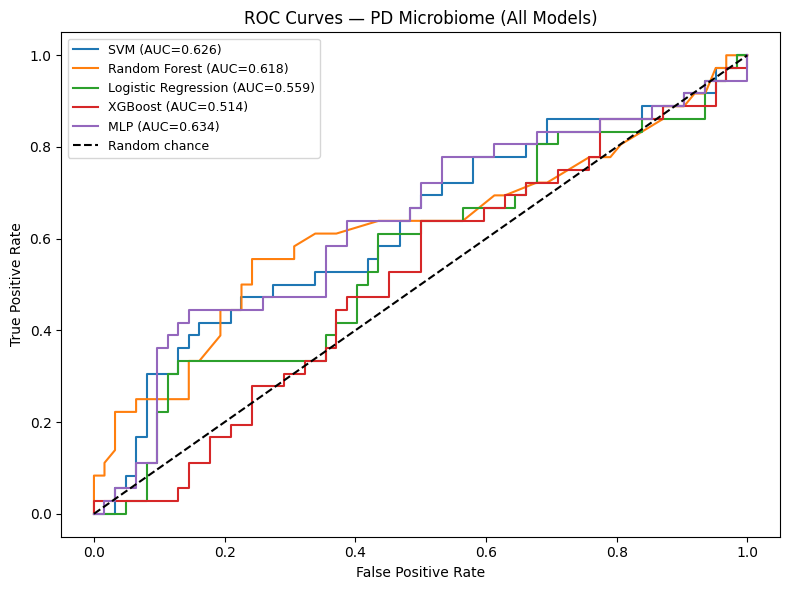

In [18]:
#ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
for name, m in [('SVM',svm3),('Random Forest',rf3),
                ('Logistic Regression',lr3),('XGBoost',xgb3),('MLP',mlp3)]:
    fpr, tpr, _ = roc_curve(y_te3, probs[name])
    auc = roc_auc_score(y_te3, probs[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — PD Microbiome (All Models)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output_dir + 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
#saving results
summary_table.to_csv(output_dir + 'master_auc_table.csv')
stats_results.to_csv(output_dir + 'statistical_analysis.csv', index=False)
coef_df.to_csv(output_dir + 'lasso_coefficients.csv', index=False)
meta_importance.to_csv(output_dir + 'metadata_feature_importance.csv', index=False)
shap_imp.to_csv(output_dir + 'shap_importance_rf.csv', index=False)
plan.to_csv(output_dir + 'experiment_plan.csv', index=False)

print("All files saved to Drive.")
print(os.listdir(output_dir))

All files saved to Drive.
['model_performance.csv', 'master_auc_comparison.png', 'precision_recall_curves.png', 'lasso_coefficients.png', 'shap_rf.png', 'experiment_plan.png', 'metadata_analysis.png', 'shap_xgb.png', 'master_auc_table.csv', 'metadata_feature_importance.csv', 'statistical_analysis.csv', 'shap_importance_rf.csv', 'lasso_coefficients.csv', 'roc_curves.png', 'experiment_plan.csv']
